# Comparing Pretrained BERT vs Fine-Tuning Strategies

This notebook compares all fine-tuning strategies trained in `results/metrics/`:
1. Training loss vs.epoch, for every model (one subplot per strategy, line style = learning rate)
2. Accuracy, precision, recall, and F1 score across models
3. Consusion matrices across models.

In [149]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Publication-style theme: clean gridlines, readble fonts
sns.set_theme(style = "whitegrid", context = "notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": 'tight',
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
})

def save_fig(fig, name):
    """
    Save a figure as a high-res PNG for slides/docs.
    """
    fig.savefig(FIGURES_DIR/f"{name}.png")

## Load metrics for every run

In [150]:
METRICS_DIR = Path("../results/metrics")

runs = {}

for metrics_path in sorted(METRICS_DIR.glob("*.json")):
    with open(metrics_path) as f:
        runs[metrics_path.stem] = json.load(f)

print(f"Loaded {len(runs)} runs:")

for run_name in runs:
    print( " - ", run_name)

Loaded 7 runs:
 -  frozen-transformer_lr1e-3
 -  frozen-transformer_lr1e-4
 -  full-finetune_lr1e-3
 -  full-finetune_lr5e-5
 -  head-only_lr1e-3
 -  head-only_lr1e-4
 -  lora_lr2e-4


## 1. Training Loss vs epoch

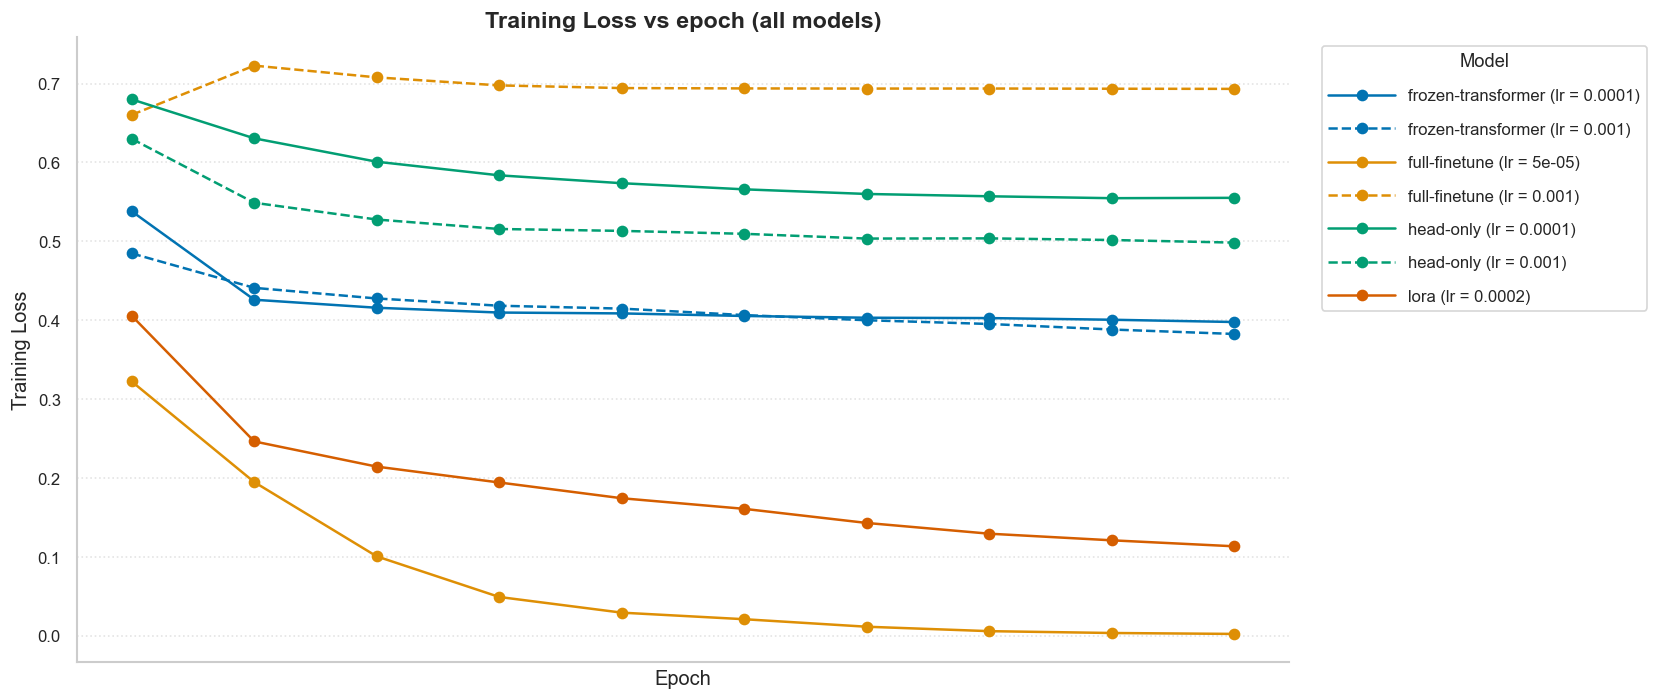

In [151]:
strategies = sorted({run["strategy"] for run in runs.values()})
linestyles = ["-", "--", "-.", ":"]
palette = dict(zip(strategies, sns.color_palette("colorblind", n_colors = len(strategies))))

fig, ax = plt.subplots(figsize = (14,6))

for strategy in strategies:
    # lowest learning rate get a solid line!
    strategy_runs = sorted(
        (run for run in runs.values() if run["strategy"] == strategy),
         key = lambda run: run["learning_rate"]
    )
    for run, linestyle in zip(strategy_runs, linestyles):
        history = pd.DataFrame(run["train_history"])
        ax.plot(
            history["epoch"], history["loss"],
            linestyle = linestyle, color = palette[strategy], marker = "o",
            linewidth = 1.5, markersize = 6,
            label = f"{strategy} (lr = {run['learning_rate']:g})"
        )
ax.set_xlabel("Epoch", fontsize = 12)
ax.set_ylabel("Training Loss", fontsize = 12)
ax.tick_params(axis = "both", labelsize = 10)
ax.set_xticks(range(1,1))
ax.set_title("Training Loss vs epoch (all models)")

ax.grid(True, color = "lightgray", linestyle = ":", alpha = 0.6)

ax.legend(
    title = "Model", bbox_to_anchor=(1.02,1), loc = "upper left", frameon = True,
    handlelength = 4.0, labelspacing = 1.1
)
sns.despine(ax = ax)
fig.tight_layout()
save_fig(fig, "loss_vs_epoch")
plt.show()

## 2. Accuracy, Precision , Recall and F1 Score

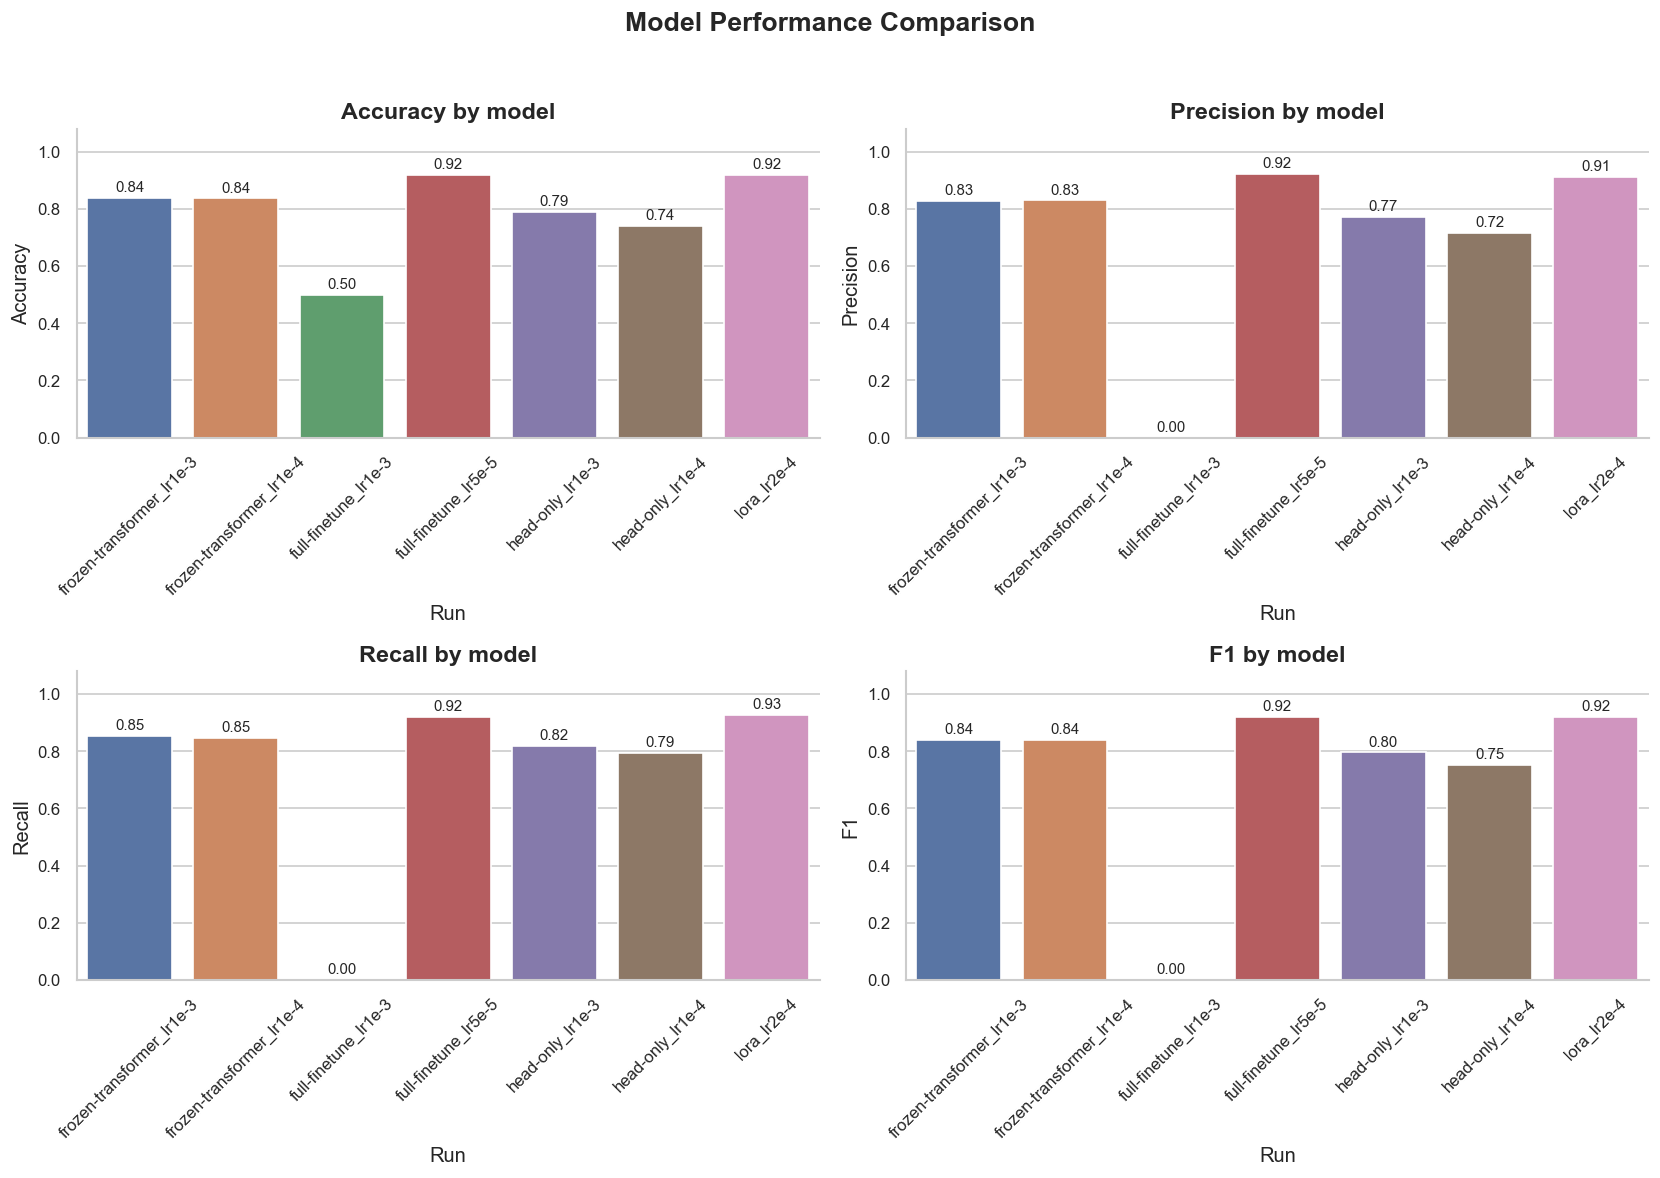

In [152]:
summary_df = pd.DataFrame([
    {
        "run_name": run_name,
        "strategy": run["strategy"],
        "learning_rate": run["learning_rate"],
        "accuracy": run["accuracy"],
        "precision": run["precision"],
        "recall": run["recall"],
        "f1": run["f1"]
    }
    for run_name, run in runs.items()
]).sort_values("run_name").reset_index(drop=True)

metrics_to_plot = ["accuracy", "precision", "recall", "f1"]

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

# Flatten axes so we can loop through them
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):

    sns.barplot(
        data=summary_df,
        x="run_name",
        y=metric,
        ax=ax
    )

    ax.set_ylim(0, 1.08)
    ax.set_xlabel("Run")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"{metric.capitalize()} by model")

    ax.tick_params(
        axis="x",
        rotation=45
    )

    # Add values above bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            fontsize=9,
            padding=2
        )

    sns.despine(ax=ax)

fig.suptitle(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

fig.tight_layout(
    rect=[0, 0, 1, 0.96]
)

save_fig(fig, "all_metrics_by_model")

plt.show()

## 3. Confusion matrics

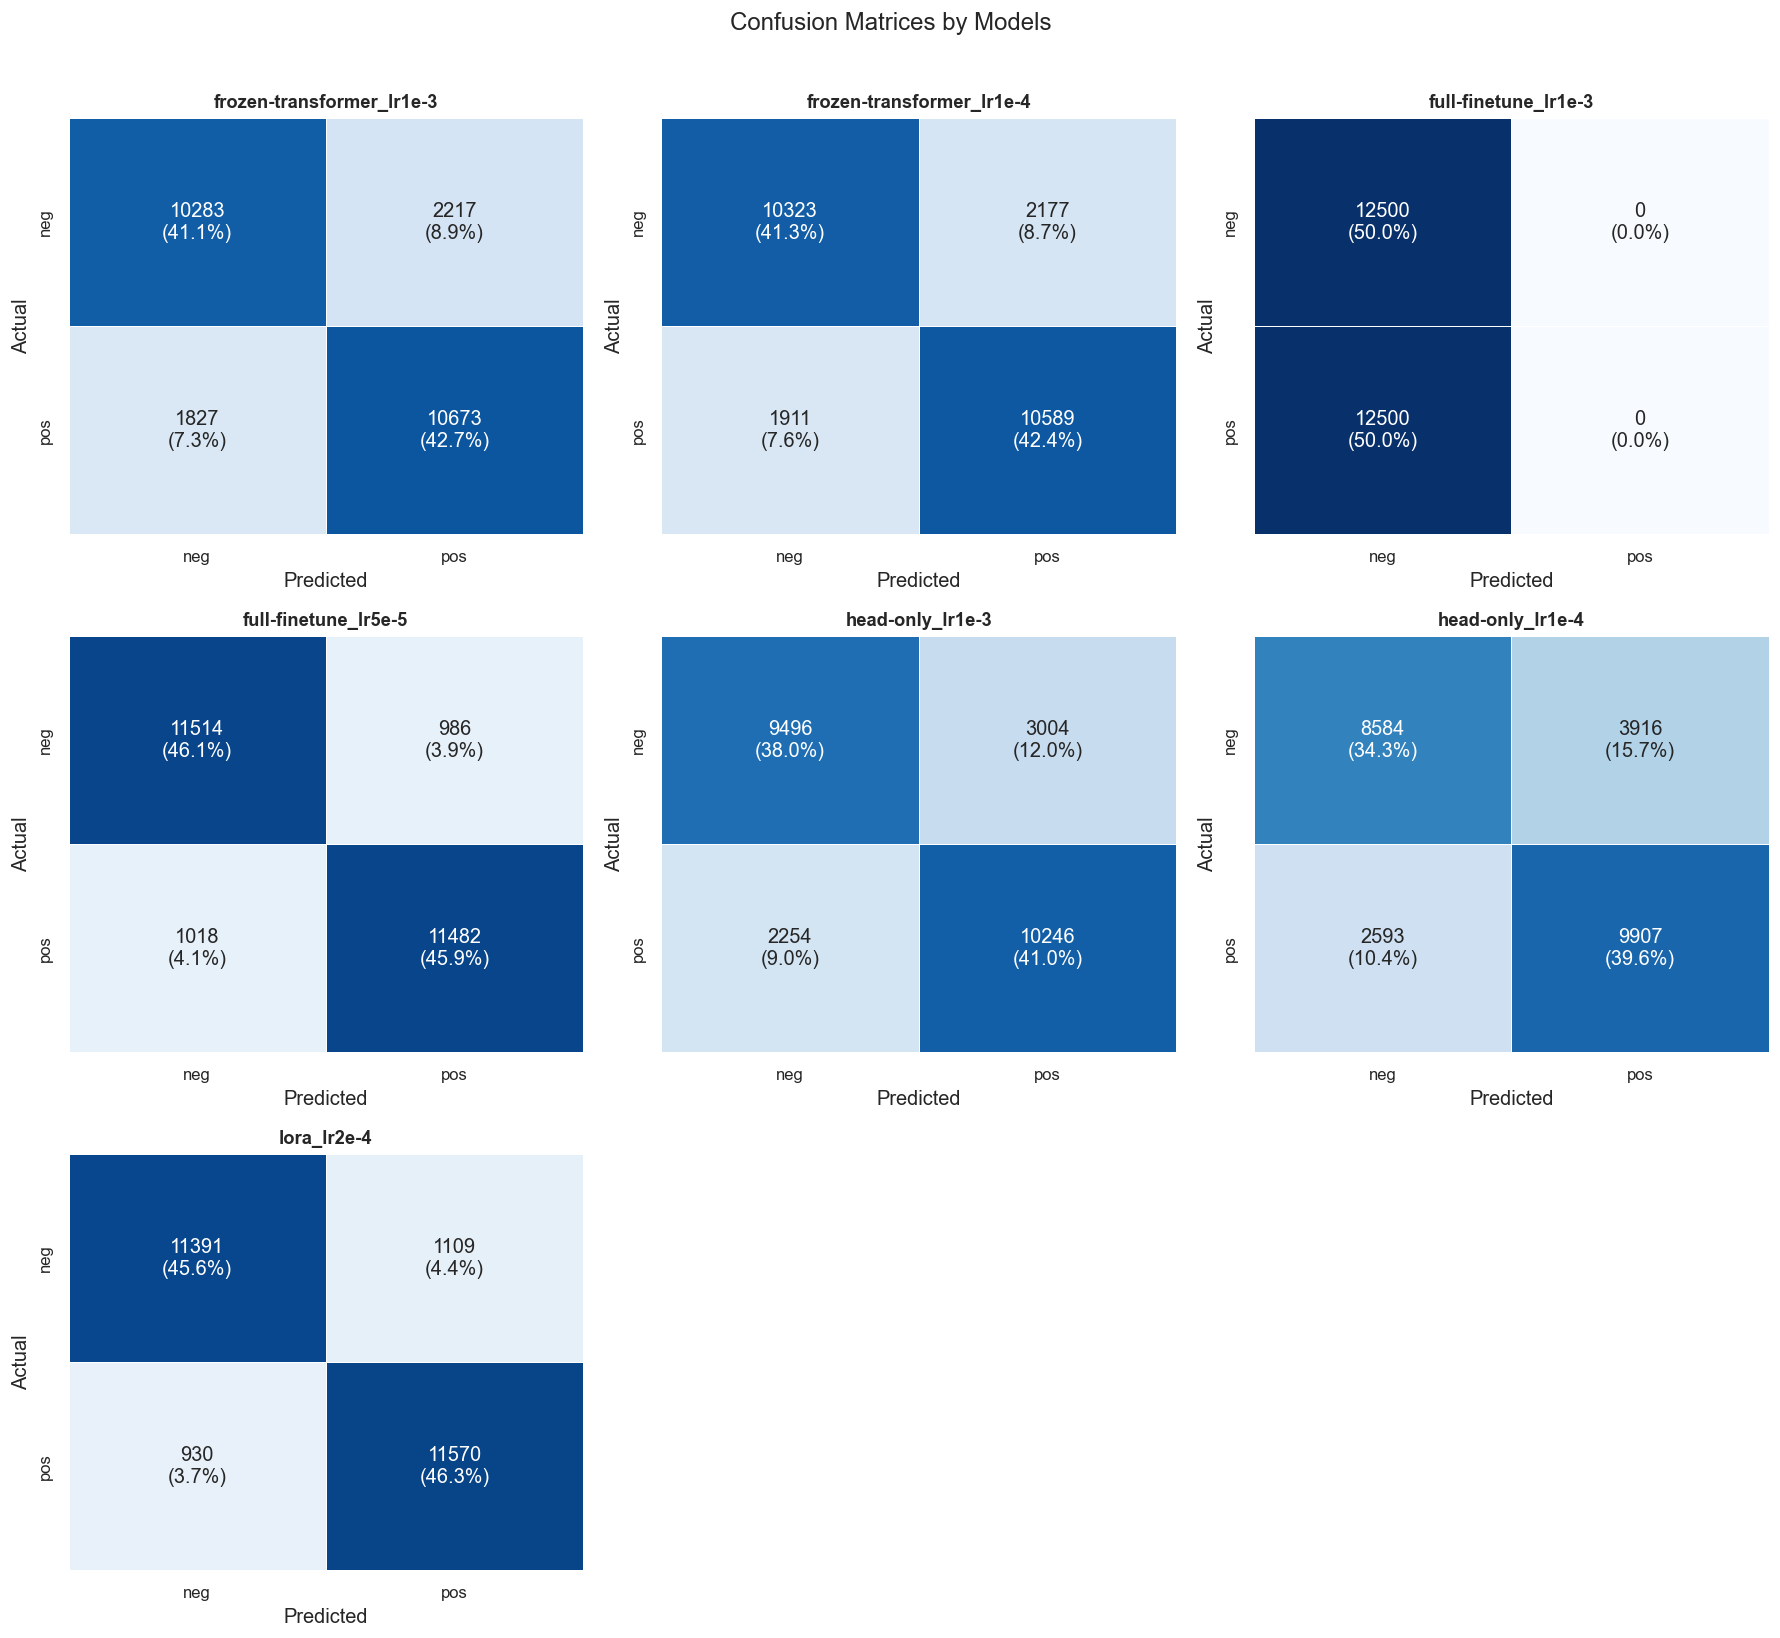

In [153]:
run_names = list(runs.keys())
n_runs = len(run_names)
n_cols = 3
n_rows = int(np.ceil(n_runs/n_cols))

vmax = max(np.array(run["confusion_matrix"]).max() for run in runs.values())

fig, axes = plt.subplots(n_rows, n_cols, figsize = (5*n_cols, 4.5*n_rows))
axes = np.array(axes).reshape(-1)

for ax, run_name in zip(axes, run_names):
    cm = np.array(runs[run_name]["confusion_matrix"])
    cm_pct = cm/cm.sum()*100
    labels = np.array([
        f"{count}\n({pct:.1f}%)" for count, pct in zip(cm.flatten(), cm_pct.flatten())
    ]).reshape(cm.shape)

    sns.heatmap(
        cm, annot = labels, fmt= "", cmap = "Blues", cbar = False, 
        vmin = 0, vmax = vmax, 
        xticklabels = ["neg", "pos"], yticklabels=["neg", "pos"], 
        linewidths=0.5, linecolor = "white", ax= ax
    )
    ax.set_title(run_name, fontsize = 11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes[n_runs:]:
    ax.axis("off")

fig.suptitle("Confusion Matrices by Models", y=1.01)
fig.tight_layout()
save_fig(fig, "confusion_matrices")
plt.show()